In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/117.atr
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/207.xws
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/212.xws
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/103.dat
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/106.hea
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/113.dat
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/202.dat
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/109.xws
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/217.dat
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/111.atr
/kaggle/input/datasets/abhishekpriya/mit-bih/mit-bih-arrhythmia-database-1.0.0/208.hea
/kaggle/input/datasets/abhishekpriya/mit-bi

In [4]:
import numpy as np

DATA_PATH = "/kaggle/input/datasets/abhishekpriya/ecg-data/ecg_data"

X_train = np.load(f"{DATA_PATH}/X_train.npy")
X_val   = np.load(f"{DATA_PATH}/X_val.npy")
X_test  = np.load(f"{DATA_PATH}/X_test.npy")

y_train = np.load(f"{DATA_PATH}/y_train.npy")
y_val   = np.load(f"{DATA_PATH}/y_val.npy")
y_test  = np.load(f"{DATA_PATH}/y_test.npy")

In [5]:
print(X_train.shape)
print(y_train.shape)

(76435, 1, 360)
(76435,)


In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [7]:
# Dataset class
class ECGDataset(Dataset):

    def __init__(self,X,y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self,idx):

        return self.X[idx], self.y[idx]

In [8]:
#create dataset
train_dataset = ECGDataset(
    X_train,
    y_train
)

val_dataset = ECGDataset(
    X_val,
    y_val
)

test_dataset = ECGDataset(
    X_test,
    y_test
)

In [9]:
#weighted sampling
counts = np.bincount(y_train)

weights = 1.0 / np.sqrt(counts)

sample_weights = weights[y_train]

sampler = WeightedRandomSampler(
    sample_weights,
    len(sample_weights),
    replacement=True
)

In [10]:
# data loader
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

**CNN + LSTM model**

In [11]:
class CNNLSTM(nn.Module):

    def __init__(self,num_classes=5):

        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.fc = nn.Sequential(

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self,x):

        x = self.cnn(x)

        x = x.permute(
            0,
            2,
            1
        )

        output,(hn,cn) = self.lstm(x)

        x = output[:,-1,:]

        x = self.fc(x)

        return x

In [12]:
#initialize model
model = CNNLSTM(
    num_classes=5
).to(device)

In [13]:
# class weight
weights = 1.0 / np.sqrt(counts)

weights = weights / weights.min()

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

In [14]:
# optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
# scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-5
)

In [15]:
# evaluation 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate(
    model,
    loader
):

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)

            output = model(X)

            pred = torch.argmax(
                output,
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            labels.extend(
                y.numpy()
            )

    accuracy = accuracy_score(
        labels,
        preds
    )

    precision = precision_score(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    recall = recall_score(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    return (
        accuracy,
        precision,
        recall,
        f1
    )

training

In [16]:
EPOCHS = 40

best_f1 = 0

patience = 10

counter = 0

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for X, y in train_loader:

        X = X.to(device)

        y = y.to(device)

        optimizer.zero_grad()

        output = model(X)

        loss = criterion(
            output,
            y
        )

        # Backpropagation
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    # Scheduler Step
    scheduler.step()

    # Validation Metrics
    acc, prec, rec, f1 = evaluate(
        model,
        val_loader
    )

    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Loss: {total_loss:.4f}"
    )

    print(
        f"Accuracy: {acc:.4f}"
    )

    print(
        f"Precision: {prec:.4f}"
    )

    print(
        f"Recall: {rec:.4f}"
    )

    print(
        f"F1 Score: {f1:.4f}"
    )

    # Save Best Model
    if f1 > best_f1:

        best_f1 = f1

        counter = 0

        torch.save(
            model.state_dict(),
            "best_cnn_lstm.pth"
        )

        print(
            "Best Model Saved"
        )

    else:

        counter += 1

        print(
            f"No Improvement ({counter}/{patience})"
        )

    # Early Stopping
    if counter >= patience:

        print(
            "\nEarly Stopping Triggered"
        )

        break


Epoch 1/40
Loss: 220.9563
Accuracy: 0.8582
Precision: 0.5906
Recall: 0.8406
F1 Score: 0.6493
Best Model Saved

Epoch 2/40
Loss: 105.0510
Accuracy: 0.8682
Precision: 0.5937
Recall: 0.8975
F1 Score: 0.6645
Best Model Saved

Epoch 3/40
Loss: 65.1511
Accuracy: 0.9368
Precision: 0.7059
Recall: 0.9359
F1 Score: 0.7714
Best Model Saved

Epoch 4/40
Loss: 48.4431
Accuracy: 0.9424
Precision: 0.7266
Recall: 0.9481
F1 Score: 0.7853
Best Model Saved

Epoch 5/40
Loss: 38.0761
Accuracy: 0.9690
Precision: 0.7962
Recall: 0.9484
F1 Score: 0.8467
Best Model Saved

Epoch 6/40
Loss: 30.3213
Accuracy: 0.9355
Precision: 0.7117
Recall: 0.9527
F1 Score: 0.7766
No Improvement (1/10)

Epoch 7/40
Loss: 25.3180
Accuracy: 0.9712
Precision: 0.8048
Recall: 0.9628
F1 Score: 0.8608
Best Model Saved

Epoch 8/40
Loss: 21.2363
Accuracy: 0.9684
Precision: 0.8038
Recall: 0.9618
F1 Score: 0.8628
Best Model Saved

Epoch 9/40
Loss: 16.9661
Accuracy: 0.9752
Precision: 0.8332
Recall: 0.9598
F1 Score: 0.8848
Best Model Saved

Ep

In [17]:
#load best model
model.load_state_dict(
    torch.load(
        "best_cnn_lstm.pth"
    )
)

<All keys matched successfully>

In [18]:
acc,prec,rec,f1 = evaluate(
    model,
    test_loader
)

print("Accuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1:",f1)

Accuracy: 0.9902930402930403
Precision: 0.9355095427582976
Recall: 0.9585618914893402
F1: 0.946659160823043


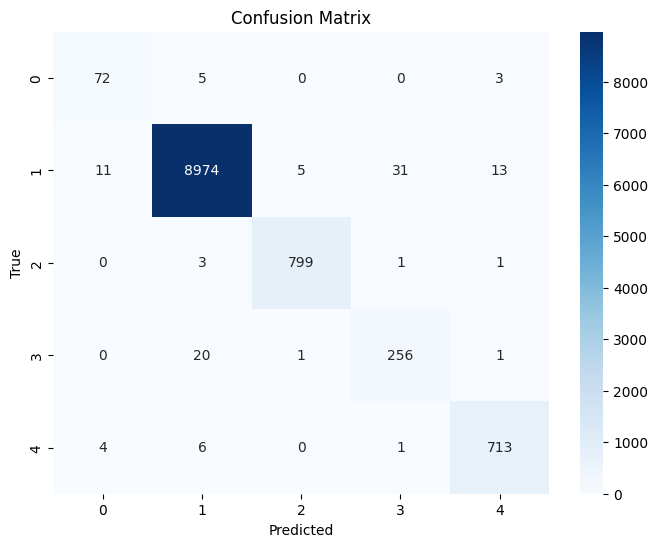

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = []
labels = []

model.eval()

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        output = model(X)

        pred = output.argmax(dim=1)

        preds.extend(
            pred.cpu().numpy()
        )

        labels.extend(
            y.numpy()
        )

cm = confusion_matrix(
    labels,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

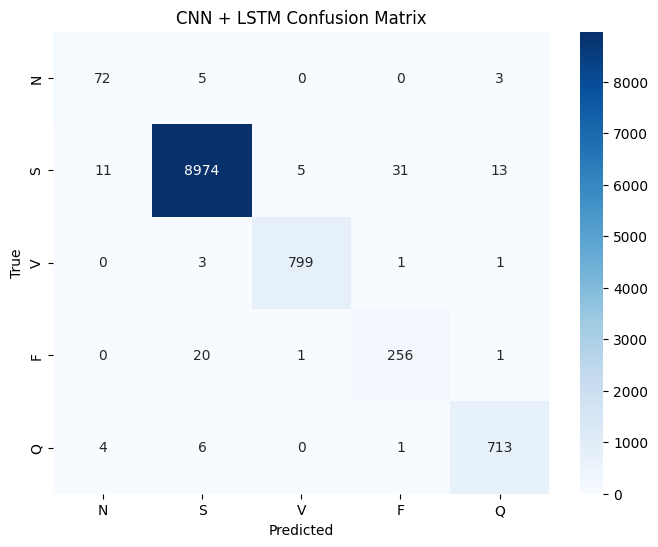

In [20]:
class_names = [
    "N",
    "S",
    "V",
    "F",
    "Q"
]
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN + LSTM Confusion Matrix")

plt.show()